# House Price Prediction 
**Author:** Aishwarya kapadnis  
**Dataset:** California Housing Dataset  
**Goal:** Predict house prices using regression models with feature engineering and hyperparameter tuning

---
## Project Pipeline
1. Data Loading & Exploration (EDA)
2. Data Preprocessing & Feature Engineering
3. Model Training (Linear Regression, Ridge, Random Forest, XGBoost)
4. Hyperparameter Tuning
5. Model Evaluation & Comparison
6. Save Final Model

## Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

## Step 2: Load Dataset

In [3]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset Shape:", df.shape)
print("\nFeatures:")
print(df.columns)

df.head()

Dataset Shape: (20640, 9)

Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Exploratory Data Analysis (EDA)

In [4]:
rows = df.shape[0]
cols = df.shape[1]

print("Rows:", rows)
print("Columns:", cols)

missing = df.isnull().sum().sum()
print("Missing Values:", missing)

print("\nStatistics:")
print(df["MedHouseVal"].describe())

Rows: 20640
Columns: 9
Missing Values: 0

Statistics:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


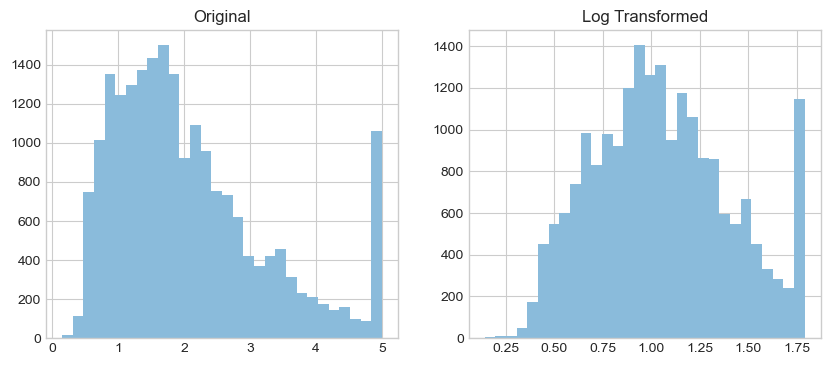

In [5]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df["MedHouseVal"], bins=30)
plt.title("Original")

plt.subplot(1,2,2)
plt.hist(np.log1p(df["MedHouseVal"]), bins=30)
plt.title("Log Transformed")

plt.show()

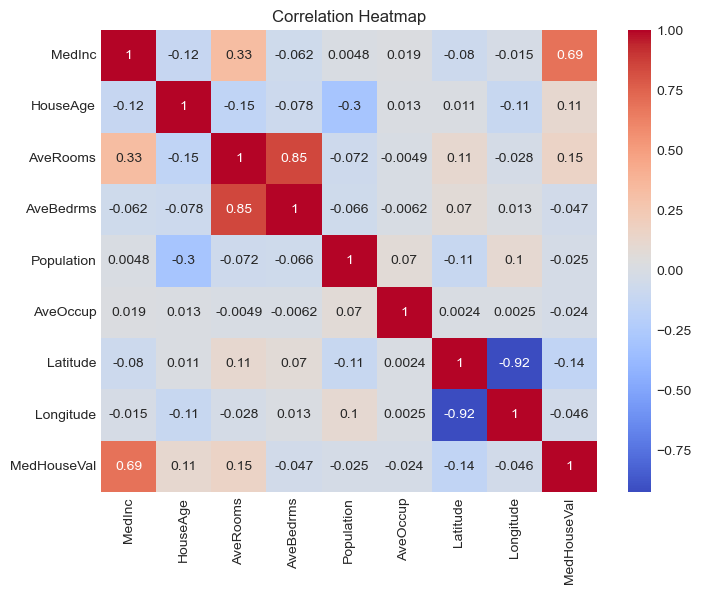

In [6]:
plt.figure(figsize=(8,6))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


#"A correlation heatmap visualizes relationships between numerical variables.Correlation values range from -1 to +1, where +1 indicates a strong positive relationship, -1 indicates a strong negative relationship, and 0 indicates no linear relationship."

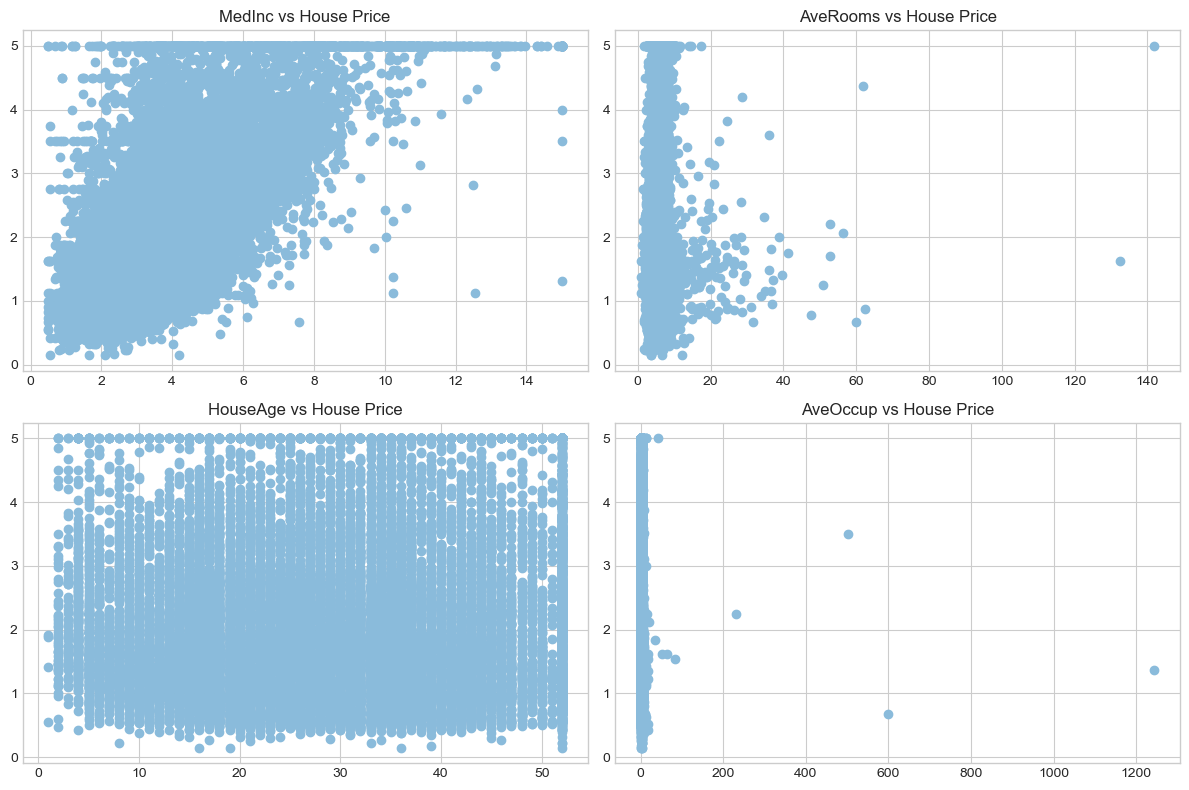

In [7]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.title("MedInc vs House Price")

plt.subplot(2,2,2)
plt.scatter(df["AveRooms"], df["MedHouseVal"])
plt.title("AveRooms vs House Price")

plt.subplot(2,2,3)
plt.scatter(df["HouseAge"], df["MedHouseVal"])
plt.title("HouseAge vs House Price")

plt.subplot(2,2,4)
plt.scatter(df["AveOccup"], df["MedHouseVal"])
plt.title("AveOccup vs House Price")

plt.tight_layout()
plt.show()

## Step 4: Feature Engineering

In [8]:
df_fe = df.copy()

df_fe["RoomsPerHousehold"] = df_fe["AveRooms"] / df_fe["AveOccup"]

df_fe["BedroomRatio"] = df_fe["AveBedrms"] / df_fe["AveRooms"]

df_fe["IncomePerRoom"] = df_fe["MedInc"] / df_fe["AveRooms"]

df_fe["log_Population"] = np.log1p(df_fe["Population"])

print(df_fe.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  RoomsPerHousehold  BedroomRatio  IncomePerRoom  \
0    -122.23        4.526           2.732919      0.146591       1.192017   
1    -122.22        3.585           2.956685      0.155797       1.330750   
2    -122.24        3.521           2.957661      0.129516       0.875637   
3    -122.25        3.413           2.283154      0.184458       0.970046   
4    -122.25        3.422           2.879646      0.172096       0.612272   

   log_Population  
0        5.777652  
1        7.784057  
2        6.208590  


## Step 5: Train-Test Split & Scaling

In [9]:
X = df_fe.drop("MedHouseVal", axis=1)
y = df_fe["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (16512, 12)
Testing Shape : (4128, 12)


## Step 6: Train Multiple Models

In [10]:
def evaluate_model(model):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("RMSE:",
          np.sqrt(mean_squared_error(y_test,y_pred)))

    print("MAE:",
          mean_absolute_error(y_test,y_pred))

    print("R2:",
          r2_score(y_test,y_pred))

In [11]:
evaluate_model(LinearRegression())

RMSE: 0.67494268209218
MAE: 0.4856527223411932
R2: 0.6523622535604761


In [12]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    print(name, ":", r2)

Linear : 0.6523622535604761
Ridge : 0.6523510671549284
Lasso : -0.00021908714592466794


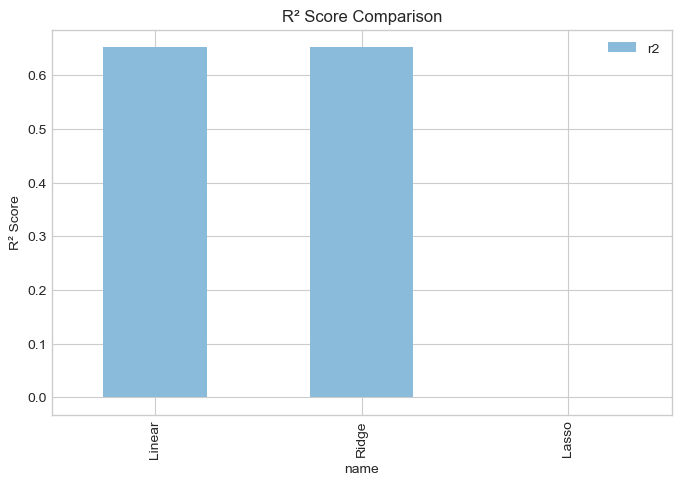

In [13]:
results_df = pd.DataFrame({
    'name': ['Linear', 'Ridge', 'Lasso'],
    'r2': [0.652, 0.652, -0.0002]
})

results_df.plot(
    x='name',
    y='r2',
    kind='bar',
    figsize=(8,5)
)

plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.show()

## Step 7: Hyperparameter Tuning (XGBoost)

In [24]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_tuned = GridSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

## Step 8: Final Model Analysis

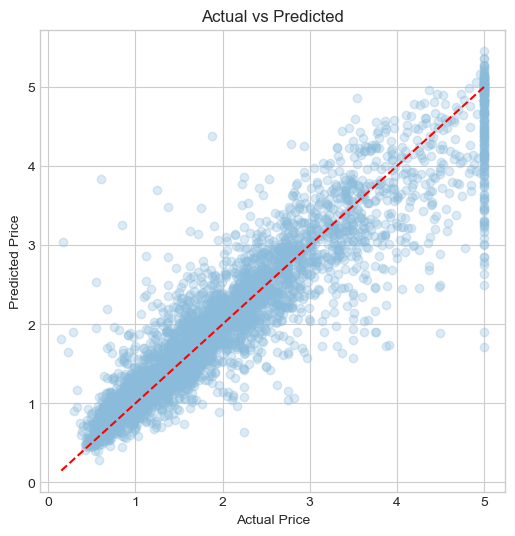

In [29]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_best, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [25]:
xgb_tuned.fit(X_train, y_train)

best_model = xgb_tuned.best_estimator_

y_pred_best = best_model.predict(X_test)

In [26]:
print(best_model)
print(y_pred_best[:10])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)
[0.5055428 0.9323459 5.2628236 2.515753  2.579393  1.6772804 2.2579334
 1.5224351 2.6935022 4.9082565]


In [27]:
print(y_test[:10])
print(y_pred_best[:10])

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
13311    1.58700
7113     1.98200
7668     1.57500
18246    3.40000
5723     4.46600
Name: MedHouseVal, dtype: float64
[0.5055428 0.9323459 5.2628236 2.515753  2.579393  1.6772804 2.2579334
 1.5224351 2.6935022 4.9082565]


In [28]:
print("Min Prediction:", y_pred_best.min())
print("Max Prediction:", y_pred_best.max())

Min Prediction: 0.28636292
Max Prediction: 5.4600844


In [32]:
%whos

Variable                    Type              Data/Info
-------------------------------------------------------
GradientBoostingRegressor   ABCMeta           <class 'sklearn.ensemble.<...>adientBoostingRegressor'>
GridSearchCV                ABCMeta           <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
Lasso                       ABCMeta           <class 'sklearn.linear_mo<...>oordinate_descent.Lasso'>
LinearRegression            ABCMeta           <class 'sklearn.linear_mo<...>._base.LinearRegression'>
RandomForestRegressor       ABCMeta           <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
Ridge                       ABCMeta           <class 'sklearn.linear_model._ridge.Ridge'>
StandardScaler              type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                           DataFrame         Shape: (20640, 12)
X_test                      ndarray           4128x12: 49536 elems, type `float64`, 396288 bytes (387.0 kb)
X_train      

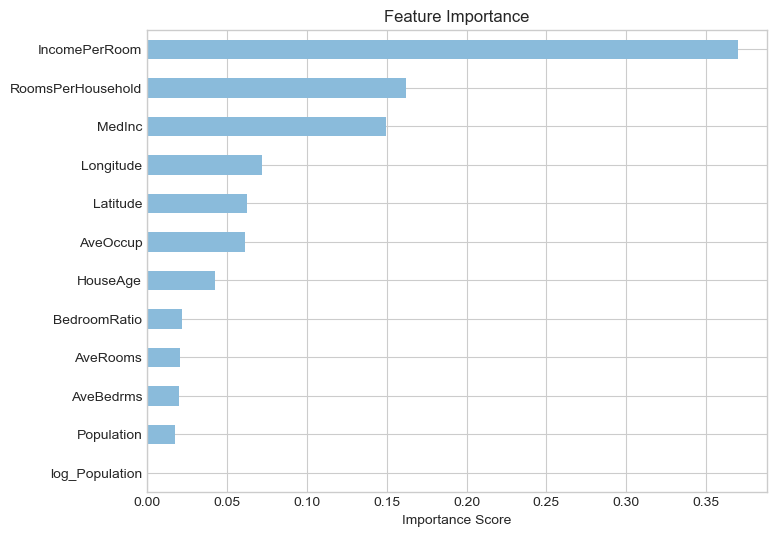

Top 5 Important Features:
Latitude             0.062285
Longitude            0.072157
MedInc               0.149427
RoomsPerHousehold    0.162369
IncomePerRoom        0.369670
dtype: float32


In [30]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values()

plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")

plt.show()

print("Top 5 Important Features:")
print(feature_importance.tail(5))

## Step 9: Save Model & Scaler

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
joblib.dump(best_model, "house_price_model.pkl")

print("R² Score :", r2_score(y_test, y_pred_best))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("MAE      :", mean_absolute_error(y_test, y_pred_best))

R² Score : 0.8474855625292964
RMSE     : 0.44705289191880887
MAE      : 0.2930350911107867
